In [219]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [220]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import  normalizeDataFrame
from src.models import  LogisticRegressionMulticlase,RandomForest,LDA
from src.data_Splitting import divideDataFrame
from src.metrics import fscore_multiclass,plot_confusion_matrix_multiclass,evaluar_modelos_multiclase,plot_many_curves_multiclase
import src.re_balanced



In [221]:

df_basket = pd.read_csv("data/EJ2/RAW/WAR_class_dev.csv")

print(df_basket.head())

print(df_basket.info())

print(df_basket.describe())

          poss           mp  raptor_total  war_total  pace_impact  war_class
0  2283.468774   826.890427     -3.369325  -0.006893     0.472195          2
1  1185.081598   567.265296     -5.389056  -0.615802     1.567405          2
2  5272.362761  2403.044668      7.084319  11.688727    -0.534305          3
3  7594.083790  3709.114977      5.532538  14.739138    -0.710111          3
4  8479.653469  3803.026613      5.089253  15.920002    -0.699135          3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6782 entries, 0 to 6781
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   poss          6782 non-null   float64
 1   mp            6782 non-null   float64
 2   raptor_total  6782 non-null   float64
 3   war_total     6782 non-null   float64
 4   pace_impact   6782 non-null   float64
 5   war_class     6782 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 318.0 KB
None
              poss           mp

In [222]:
missing_values = df_basket.isnull().sum()
print("Valores faltantes por columna:\n", missing_values)

duplicados = df_basket.duplicated().sum()
print("Número de registros duplicados:", duplicados)


Valores faltantes por columna:
 poss            0
mp              0
raptor_total    0
war_total       0
pace_impact     0
war_class       0
dtype: int64
Número de registros duplicados: 0


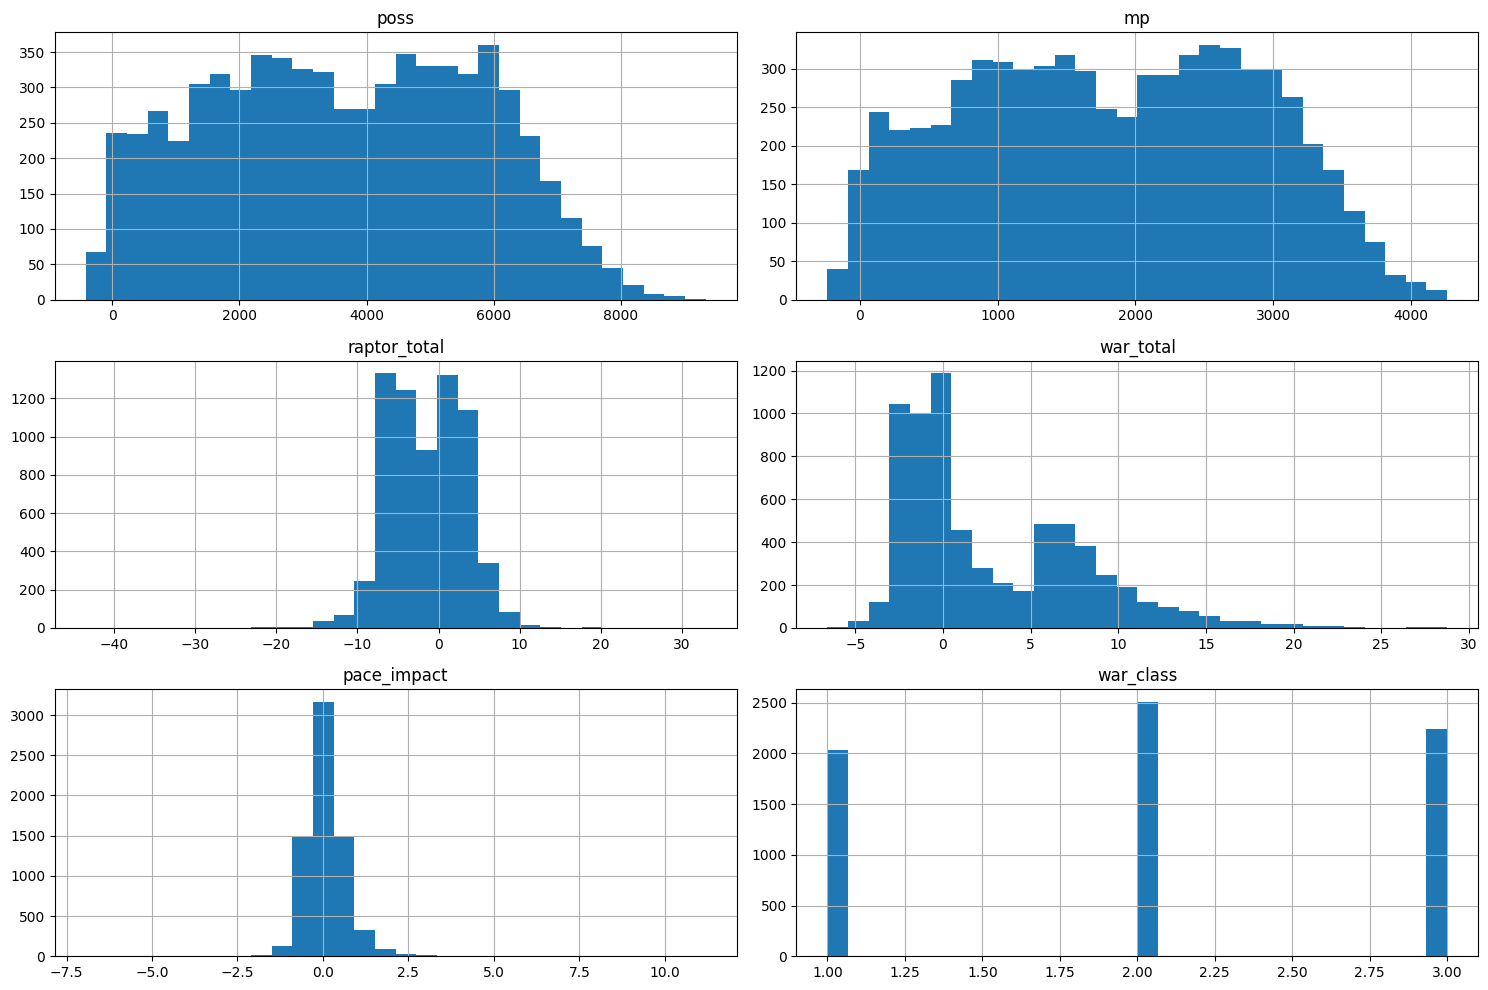

In [223]:


# Seleccionar variables numéricas
num_cols = df_basket.select_dtypes(include='number').columns

# Crear histogramas para cada variable numérica
df_basket[num_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()


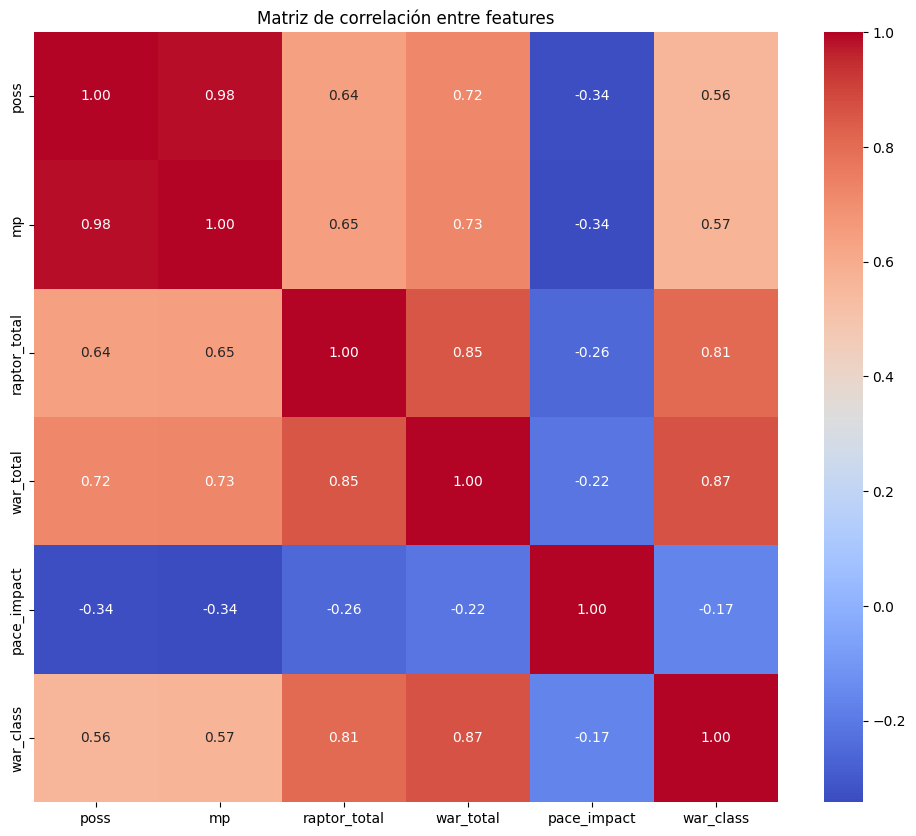

In [224]:

# Calcular la matriz de correlación
corr_matrix = df_basket.corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación entre features")
plt.show()


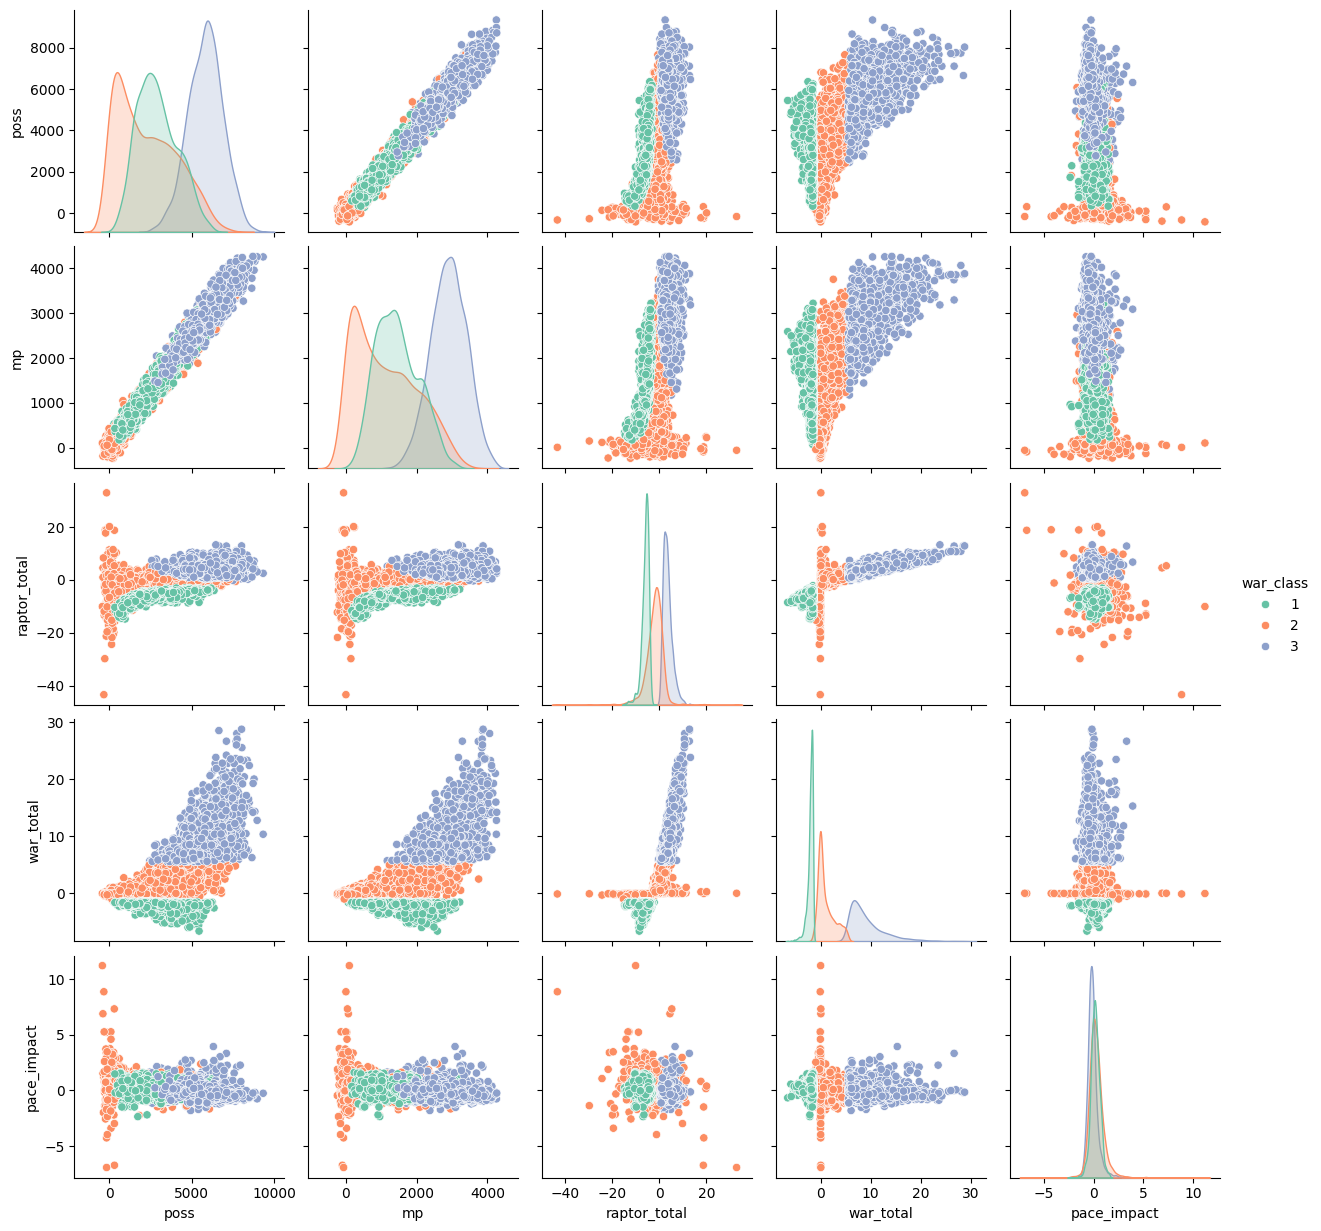

In [225]:

# Suponiendo que df es tu DataFrame y "war_class" es la columna de la variable objetivo
sns.pairplot(df_basket, hue="war_class", palette="Set2")
plt.show()

<Axes: xlabel='war_class', ylabel='Count'>

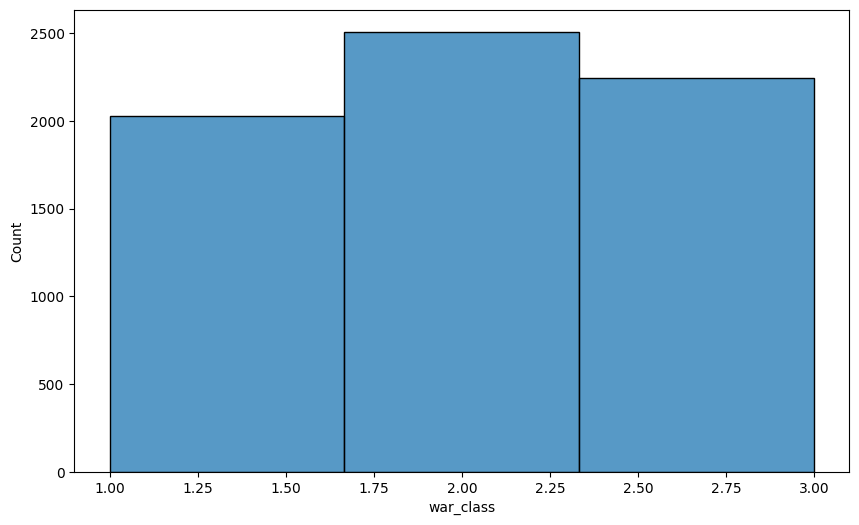

In [226]:
plt.figure(figsize=(10, 6))
sns.histplot(df_basket["war_class"],bins=3, kde=False)

In [227]:
df_war_class_dev = df_basket.copy()

df_war_class_dev = df_war_class_dev.drop(columns=["war_total"])

df_war_class_dev.to_csv("data/EJ2/PROCESSED/WAR_class_dev_processed.csv", index=False)

train,val= divideDataFrame(df_war_class_dev, 0.8)

train_normalized,val_normalized,mean,std,num_cols = normalizeDataFrame(train,val,["war_class"])




In [228]:
LDA_model = LDA()

multiClass_regresion= LogisticRegressionMulticlase()

random_forest_model=  RandomForest()

x_train = train_normalized.drop(columns=["war_class"])
y_train = train_normalized["war_class"]

x_val = val_normalized.drop(columns=["war_class"])
y_val = val_normalized["war_class"]

In [229]:
print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (5426, 4)
y_train shape: (5426,)
X_val shape: (1356, 4)
y_val shape: (1356,)


In [230]:
LDA_model.fit(x_train, y_train)

y_predicciones_LDA = LDA_model.predict(x_val)
y_probabilidades_LDA = LDA_model.predict_proba(x_val)


multiClass_regresion.fit(x_train, y_train)

y_predicciones_multiClass_regresion = multiClass_regresion.predict(x_val)
y_probabilidades_multiClass_regresion = multiClass_regresion.predict_proba(x_val)

random_forest_model.fit(x_train, y_train)

y_prediccioens_random_forest = random_forest_model.predict(x_val)
y_probabilidades_random_forest = random_forest_model.predict_proba(x_val)




In [231]:
probabilidades_test = {
    "LDA": y_probabilidades_LDA,
    "RegresionMultiClase": y_probabilidades_multiClass_regresion,
    "RandomForest": y_probabilidades_random_forest,
}

predicciones_test = {
    "LDA": y_predicciones_LDA,
    "RegresionMultiClase": y_predicciones_multiClass_regresion,
    "RandomForest": y_prediccioens_random_forest,
}

                     Accuracy  Precision    Recall  F1 Score   AUC ROC  \
LDA                  0.904130   0.859873  0.910501  0.902845  0.969675   
RegresionMultiClase  0.882006   0.899767  0.887649  0.881434  0.948628   
RandomForest         0.966077   0.955607  0.967345  0.966521  0.989050   

                       AUC PR  
LDA                  0.930662  
RegresionMultiClase  0.907924  
RandomForest         0.138474  
matriz de confusión LDA


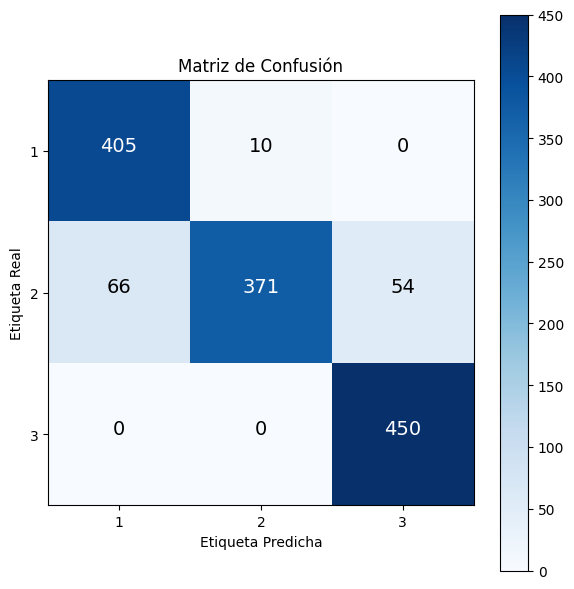

matriz de confusión RegresionMultiClase


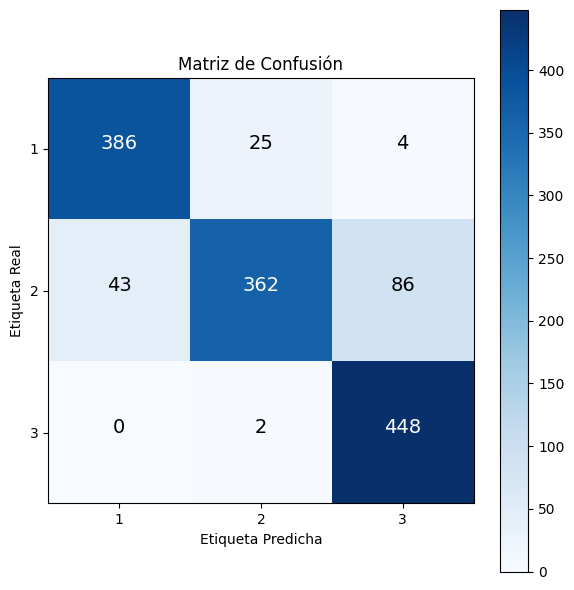

matriz de confusión RandomForest


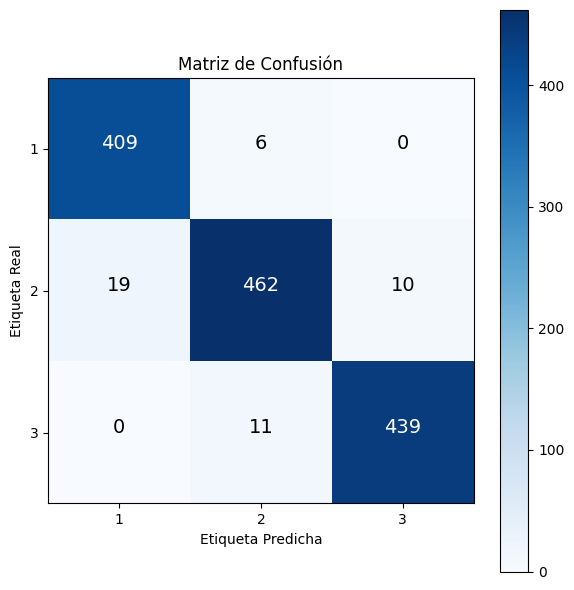

In [232]:
resultados_dict={}
for nombre  in predicciones_test:
    resultados_dict[nombre] = (predicciones_test[nombre], probabilidades_test[nombre])

df_resultados_test = evaluar_modelos_multiclase(y_val, resultados_dict)
print(df_resultados_test)

print("matriz de confusión LDA")
plot_confusion_matrix_multiclass(y_val, predicciones_test["LDA"])
print("matriz de confusión RegresionMultiClase")
plot_confusion_matrix_multiclass(y_val, predicciones_test["RegresionMultiClase"])
print("matriz de confusión RandomForest")
plot_confusion_matrix_multiclass(y_val, predicciones_test["RandomForest"])




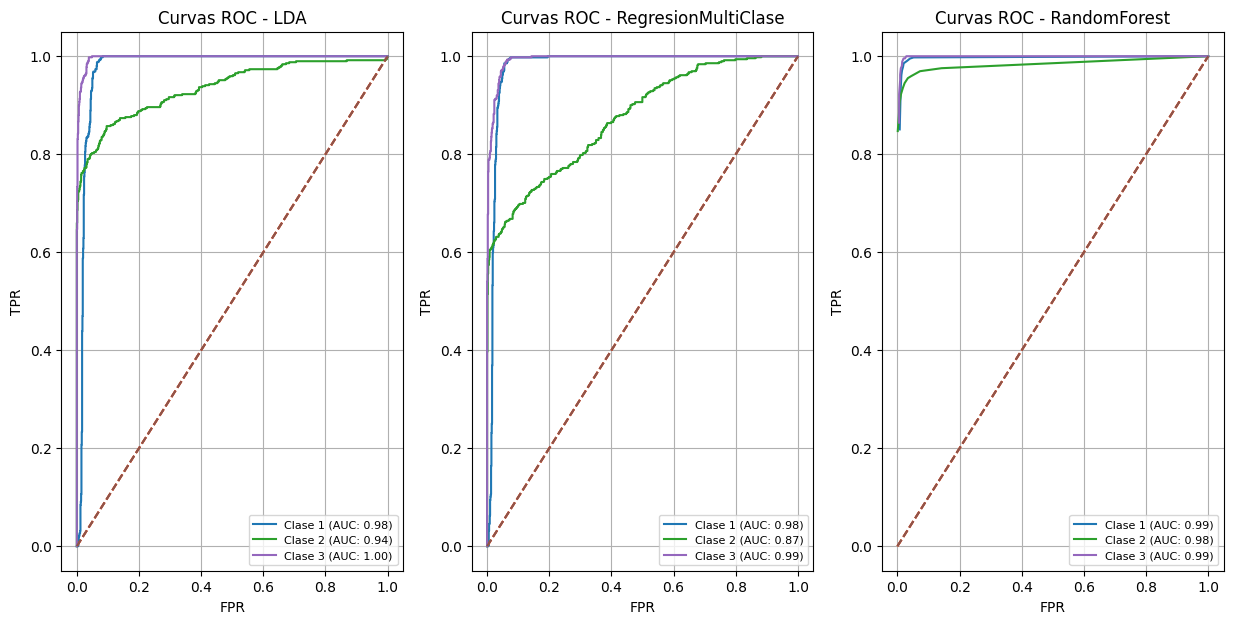

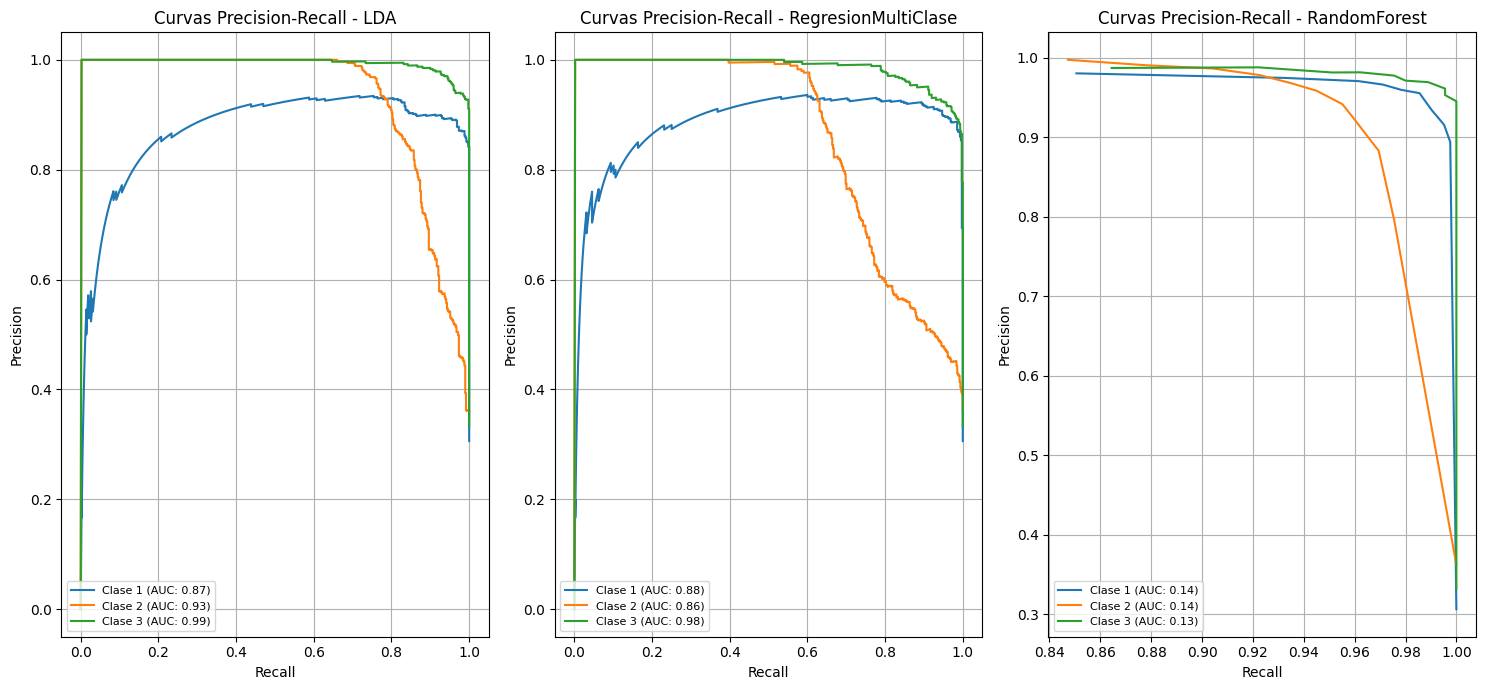

In [233]:
probabilidades_dict = {}
for nombre in probabilidades_test:
    probabilidades_dict[nombre] = probabilidades_test[nombre]

plot_many_curves_multiclase(y_val, probabilidades_dict)

In [234]:
estimators=np.linspace(5, 15, 3).astype(int)
depths=np.linspace(5, 25,5 ).astype(int)
resultados=[]

for estimator in estimators:
    for depth in depths:
        random_forest=  RandomForest(n_estimators=estimator,max_depth=depth)
        random_forest.fit(x_train, y_train)
        
        result = random_forest.predict(x_val)
        resultados.append((estimator,depth,fscore_multiclass(y_val,result)))

mejor_estimador = max(resultados, key=lambda x: x[2])
print("Mejor fscore:", mejor_estimador[2])
print("Mejor estimador:", mejor_estimador[0])
print("Mejor profundidad:", mejor_estimador[1])


Mejor fscore: 0.9701522959244898
Mejor estimador: 15
Mejor profundidad: 10


In [235]:
lambdas=[0.0001,0.001,0.01,0.1,1,10]
resultados_lambda=[]
for lambd in lambdas:
    l= LogisticRegressionMulticlase(lambda_=lambd)
    l.fit(x_train, y_train)
    result = l.predict(x_val)
    resultados_lambda.append((lambd,fscore_multiclass(y_val,result)))
mejor_lambda = max(resultados_lambda, key=lambda x: x[1])
print("Mejor fscore:", mejor_lambda[1])
print("Mejor lambda:", mejor_lambda[0])


Mejor fscore: 0.8814339356494507
Mejor lambda: 0.0001


In [236]:
df_test=pd.read_csv("data/EJ2/RAW/WAR_class_test.csv")

df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1696 entries, 0 to 1695
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   poss          1696 non-null   float64
 1   mp            1696 non-null   float64
 2   raptor_total  1696 non-null   float64
 3   war_total     1696 non-null   float64
 4   pace_impact   1696 non-null   float64
 5   war_class     1696 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 79.6 KB


In [237]:
train_dev= pd.concat([train,val], axis=0)

mean=train_dev.mean()
std=train_dev.std()

X_dev = train_dev.drop(columns=["war_class"])

mean=X_dev.mean()
std=X_dev.std()

X_dev = (X_dev - mean) / std
y_dev = train_dev["war_class"]

In [238]:
x_test = df_test.drop(columns=["war_class","war_total"])
y_test = df_test["war_class"]

x_test = (x_test - mean) / std


In [239]:
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)
print("X_dev shape:", X_dev.shape)
print("y_dev shape:", y_dev.shape)

X_test shape: (1696, 4)
y_test shape: (1696,)
X_dev shape: (6782, 4)
y_dev shape: (6782,)


In [240]:
best_random_forest=  RandomForest(n_estimators=mejor_estimador[0],max_depth=mejor_estimador[1])
best_random_forest.fit(X_dev, y_dev)

y_predicciones_dev_forest = best_random_forest.predict(x_test)
y_probabilidades_dev_forest = best_random_forest.predict_proba(x_test)

best_logistic_regression= LogisticRegressionMulticlase(lambda_=mejor_lambda[0])
best_logistic_regression.fit(X_dev, y_dev)

y_predicciones_dev_logistic = best_logistic_regression.predict(x_test)
y_probabilidades_dev_logistic = best_logistic_regression.predict_proba(x_test)


LDA_model= LDA()
LDA_model.fit(X_dev, y_dev)
y_predicciones_dev_LDA = LDA_model.predict(x_test)
y_probabilidades_dev_LDA = LDA_model.predict_proba(x_test)



In [241]:
probabilidades_test = {
    "LDA": y_probabilidades_dev_LDA,
    "RegresionMultiClase": y_probabilidades_dev_logistic,
    "RandomForest": y_probabilidades_dev_forest,
}

predicciones_test = {
    "LDA": y_predicciones_dev_LDA,
    "RegresionMultiClase": y_predicciones_dev_logistic,
    "RandomForest": y_predicciones_dev_forest,
}

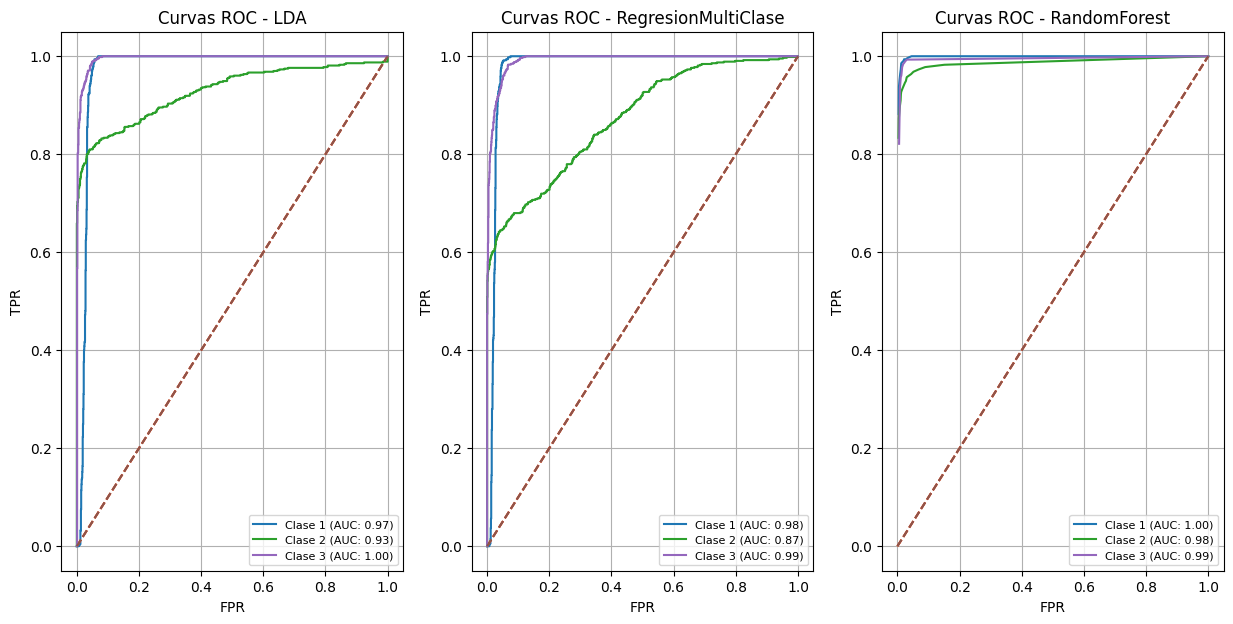

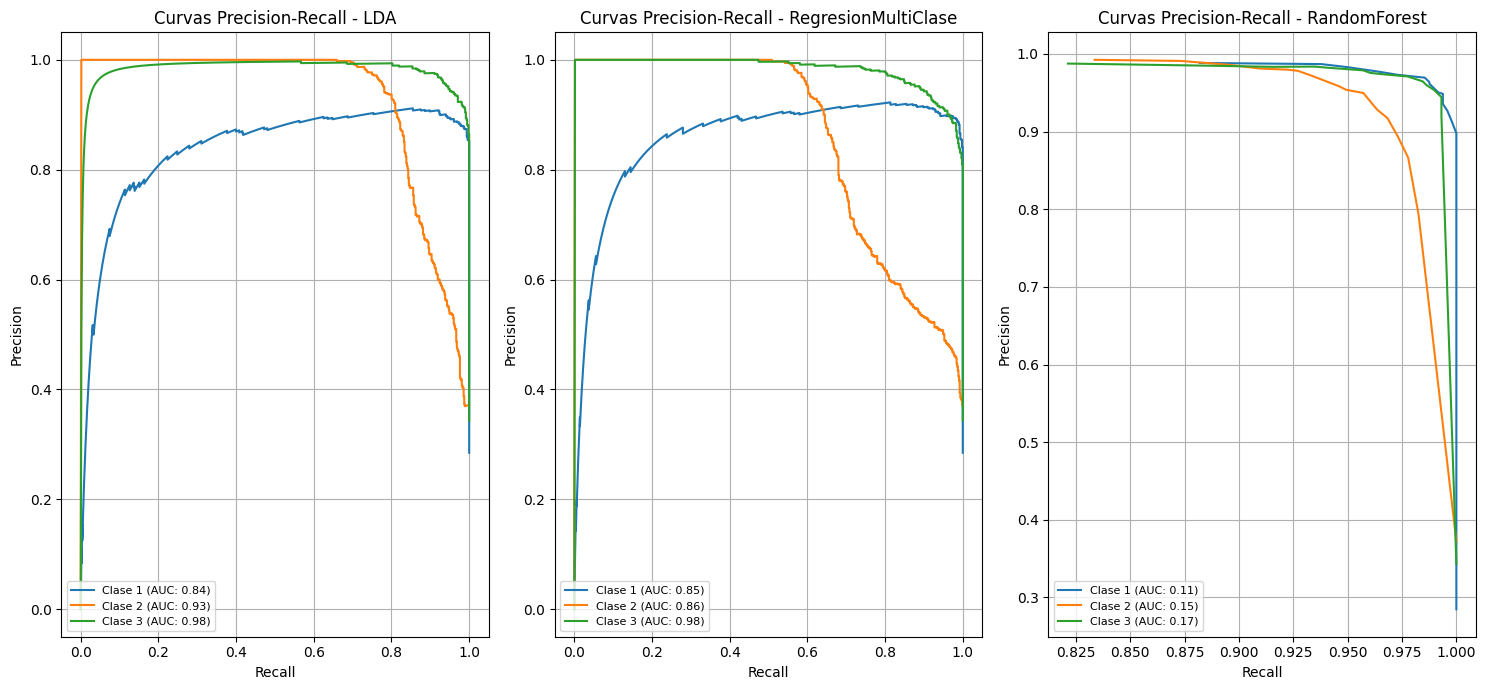

In [242]:
probabilidades_dict = {}
for nombre in probabilidades_test:
    probabilidades_dict[nombre] = probabilidades_test[nombre]

plot_many_curves_multiclase(y_test, probabilidades_dict)

                     Accuracy  Precision    Recall  F1 Score   AUC ROC  \
LDA                  0.905071   0.863309  0.914331  0.904394  0.965322   
RegresionMultiClase  0.874410   0.880228  0.883887  0.874451  0.946957   
RandomForest         0.964623   0.961694  0.966444  0.965473  0.989861   

                       AUC PR  
LDA                  0.914810  
RegresionMultiClase  0.898272  
RandomForest         0.147536  
matriz de confusión LDA


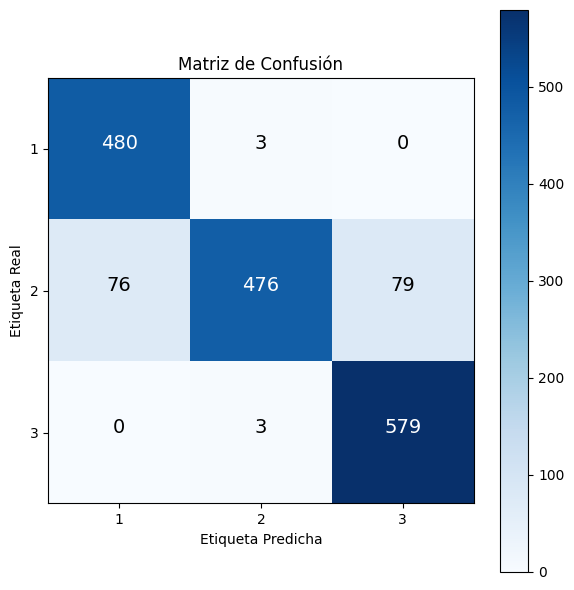

matriz de confusión RegresionMultiClase


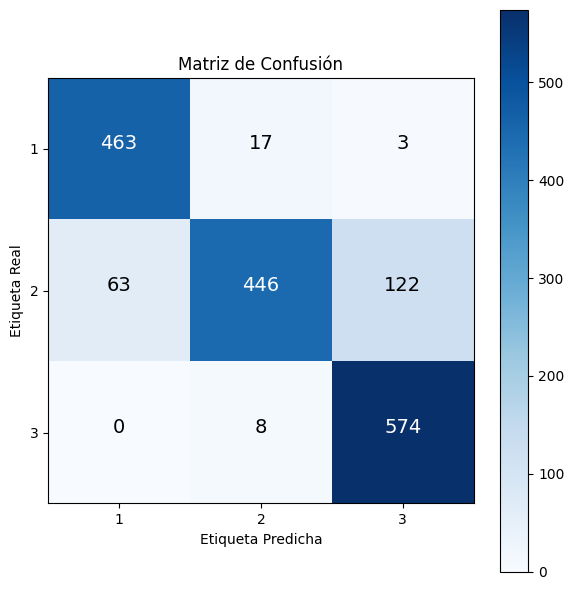

matriz de confusión RandomForest


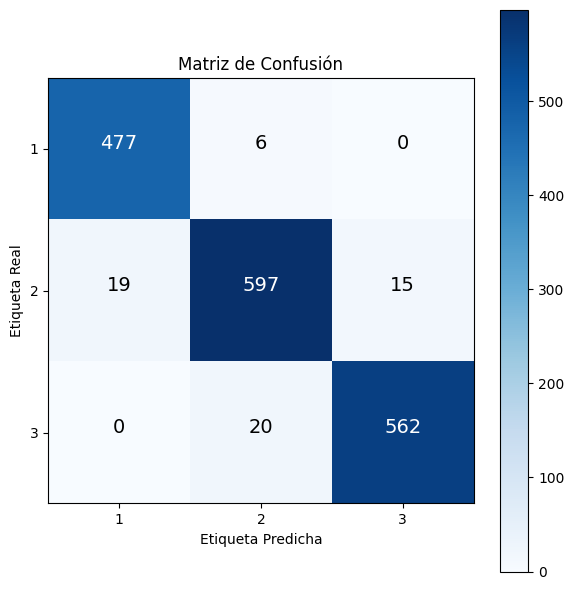

In [243]:
resultados_dict={}
for nombre  in predicciones_test:
    resultados_dict[nombre] = (predicciones_test[nombre], probabilidades_test[nombre])

df_resultados_test = evaluar_modelos_multiclase(y_test, resultados_dict)
print(df_resultados_test)

print("matriz de confusión LDA")
plot_confusion_matrix_multiclass(y_test, predicciones_test["LDA"])
print("matriz de confusión RegresionMultiClase")
plot_confusion_matrix_multiclass(y_test, predicciones_test["RegresionMultiClase"])
print("matriz de confusión RandomForest")
plot_confusion_matrix_multiclass(y_test, predicciones_test["RandomForest"])